In [1]:
import numpy as np # для работы с массивами
import pandas as pd # для работы с DataFrame 
from sklearn import datasets # для импорта данных
import seaborn as sns # для визуализации статистических данных
import matplotlib.pyplot as plt # для построения графиков

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']
boston_data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)
boston_data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
boston_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
boston_data[['CHAS', 'LSTAT', 'CRIM','RM']].describe()

,CHAS,LSTAT,CRIM,RM
count,506.000000,506.000000,506.000000,506.000000
mean,0.069170,12.653063,3.613524,6.284634
std,0.253994,7.141062,8.601545,0.702617
min,0.000000,1.730000,0.006320,3.561000
25%,0.000000,6.950000,0.082045,5.885500
50%,0.000000,11.360000,0.256510,6.208500
75%,0.000000,16.955000,3.677083,6.623500
max,1.000000,37.970000,88.976200,8.780000


In [5]:
# составляем матрицу наблюдений и вектор целевой переменной
A = np.column_stack((np.ones(506), boston_data[['CHAS', 'LSTAT', 'CRIM','RM']]))
y = boston_data[['PRICE']]
# вычисляем OLS-оценку для коэффициентов без стандартизации
w_hat=np.linalg.inv(A.T@A)@A.T@y
print(w_hat.values)

[[-1.92052548]
 [ 3.9975594 ]
 [-0.58240212]
 [-0.09739445]
 [ 5.07554248]]


>Чтобы говорить о важности влияния признаков на модель, нужно строить её на стандартизированных данных.

Помним, что для построения стандартизированной линейной регрессии нам не нужен вектор свободных коэффициентов, а значит и столбец из единиц тоже не понадобится.

Сначала центрируем векторы, которые находятся в столбцах матрицы *A*. Для этого вычтем среднее, вычисленное по строкам матрицы *A* в каждом столбце, с помощью метода `mean()`. Затем разделим результат на длины центрированных векторов, вычисленных с помощью функции `linalg.norm()`.

In [6]:
# составляем матрицу наблюдений без дополнительного столбца из единиц
A = boston_data[['CHAS', 'LSTAT', 'CRIM','RM']]
y = boston_data[['PRICE']]
# стандартизируем векторы в столбцах матрицы A
A_cent = A - A.mean(axis=0) #центрируем векторы
A_st = A_cent/np.linalg.norm(A_cent, axis=0)
A_st.describe().round(2)

,CHAS,LSTAT,CRIM,RM
count,506.00,506.00,506.00,506.00
mean,-0.00,-0.00,-0.00,-0.00
std,0.04,0.04,0.04,0.04
min,-0.01,-0.07,-0.02,-0.17
25%,-0.01,-0.04,-0.02,-0.03
50%,-0.01,-0.01,-0.02,-0.00
75%,-0.01,0.03,0.00,0.02
max,0.16,0.16,0.44,0.16


Теперь векторы имеют одинаковые средние значения и стандартные отклонения. Если вычислить длину каждого из векторов, мы увидим, что они будут равны 1:

In [7]:
print(np.linalg.norm(A_st, axis=0))

[1. 1. 1. 1.]


Для получения стандартизированных коэффициентов нам также понадобится стандартизация целевой переменной  по тому же принципу:

In [8]:
# стандартизируем вектор целевой переменной
y_cent = y - y.mean()
y_st = y_cent/np.linalg.norm(y_cent)

In [9]:
# вычислим OLS-оценку для стандартизированных коэффициентов
w_hat_st=np.linalg.inv(A_st.T@A_st)@A_st.T@y_st
print(w_hat_st.values)

[[ 0.11039956]
 [-0.45220423]
 [-0.09108766]
 [ 0.38774848]]


In [10]:
# матрица Грама
A_st.T @ A_st

,CHAS,LSTAT,CRIM,RM
CHAS,1.000000,-0.053929,-0.055892,0.091251
LSTAT,-0.053929,1.000000,0.455621,-0.613808
CRIM,-0.055892,0.455621,1.000000,-0.219247
RM,0.091251,-0.613808,-0.219247,1.000000


In [11]:
x = np.array([12,8]).T
x_cent = x - x.mean(axis=0)
x_st = x_cent/np.linalg.norm(x_cent, axis=0)

In [12]:
np.round(x_st, decimals=3)

array([ 0.707, -0.707])

In [13]:
print(np.linalg.norm(x_st, axis=0))

0.9999999999999999


## <center> **КОРРЕЛЯЦИОННАЯ МАТРИЦА**

>В этом модуле мы будем говорить именно о **корреляции Пирсона**. Она измеряет тесноту линейных связей между непрерывными числовыми факторами и может принимать значения от -1 до +1.


Как и любая статистическая величина, корреляция бывает **генеральной** и **выборочной**. Разница очень тонкая, и мы подробнее разберём её в модуле по теории вероятностей.

>**Генеральная (истинная) корреляция** — это теоретическая величина, которая отражает общую линейную зависимость между случайными величинами Xi и Xj. Забегая вперёд скажем, что данная характеристика является абстрактной и вычисляется для **генеральных совокупностей** — всех возможных реализаций Xi и Xj. В природе такой величины не существует, она есть только в теории вероятностей.

>**Выборочная корреляция** — это корреляция, вычисленная на ограниченной выборке. Это уже ближе к нашей теме. Выборочная корреляция отражает линейную взаимосвязь между факторами xi и xj, реализации которых представлены в выборке.

 В *NumPy* матрица корреляций вычисляется функцией `np.corrcoef()`:

In [14]:
x_1 = np.array([1, 2, 6])
x_2 = np.array([3000, 1000, 2000])
np.corrcoef(x_1, x_2)

array([[ 1.        , -0.18898224],
       [-0.18898224,  1.        ]])

Вспомним классификацию связей факторов, которую мы рассматривали в модуле «EDA-2. Математическая статистика в контексте EDA»:

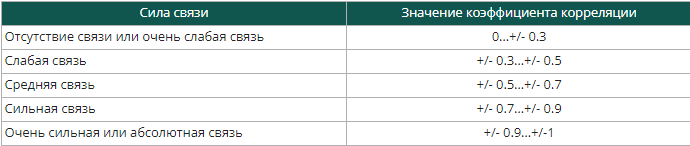

In [15]:
x_1 = np.array([5, 1, 2])
x_2 = np.array([4, 2, 8])
np.corrcoef(x_1, x_2)

array([[1.        , 0.05241424],
       [0.05241424, 1.        ]])

In [20]:
x_1 = np.array([5.1, 1.8, 2.1, 10.3, 12.1, 12.6])
x_2 = np.array([10.2, 3.7, 4.1, 20.5, 24.2, 24.1])
x_3 = np.array([2.5, 0.9, 1.1, 5.1, 6.1, 6.3])

In [40]:
A = np.array([x_1, x_2, x_3])
G = A.T@A
G

array([[136.3 ,  49.17,  55.28, 274.38, 323.8 , 325.83],
       [ 49.17,  17.74,  19.94,  98.98, 116.81, 117.52],
       [ 55.28,  19.94,  22.43, 111.29, 131.34, 132.2 ],
       [274.38,  98.98, 111.29, 552.35, 651.84, 655.96],
       [323.8 , 116.81, 131.34, 651.84, 769.26, 774.11],
       [325.83, 117.52, 132.2 , 655.96, 774.11, 779.26]])

In [26]:
np.linalg.matrix_rank(A)

3

In [42]:
x_1 = np.array([5.1, 1.8, 2.1, 10.3, 12.1, 12.6])
x_2 = np.array([10.2, 3.7, 4.1, 20.5, 24.2, 24.1])
x_3 = np.array([2.5, 0.9, 1.1, 5.1, 6.1, 6.3])
C = np.corrcoef([x_1, x_2, x_3])
print('Rank:', np.linalg.matrix_rank(C))
print('Determinant: {:.7f}'.format(np.linalg.det(C)))
print(C)

Rank: 3
Determinant: 0.0000005
[[1.         0.99925473 0.99983661]
 [0.99925473 1.         0.99906626]
 [0.99983661 0.99906626 1.        ]]
